In [ ]:
# This Python 3 environment comes with many helpful analytics libraries installed
# It is defined by the kaggle/python Docker image: https://github.com/kaggle/docker-python
# For example, here's several helpful packages to load

import numpy as np # linear algebra
import pandas as pd # data processing, CSV file I/O (e.g. pd.read_csv)

# Input data files are available in the read-only "../input/" directory
# For example, running this (by clicking run or pressing Shift+Enter) will list all files under the input directory

import os
for dirname, _, filenames in os.walk('/kaggle/input'):
    for filename in filenames:
        print(os.path.join(dirname, filename))

# You can write up to 20GB to the current directory (/kaggle/working/) that gets preserved as output when you create a version using "Save & Run All" 
# You can also write temporary files to /kaggle/temp/, but they won't be saved outside of the current session

In [1]:
import numpy as np
import matplotlib.pyplot as plt
import seaborn as sns
import warnings
warnings.filterwarnings('ignore')
import pandas as pd

In [4]:
df=pd.read_csv('/kaggle/input/datasets/abrerjawod/student-mental-health-and-burnout-dataset/Social_media_impact_on_life.csv')

# Checking the first 5 records¶

In [5]:
df.head(5)

,Student_ID,Age,Gender,Academic_Level,Country,Avg_Daily_Usage_Hours,Most_Used_Platform,Affects_Academic_Performance,Sleep_Hours_Per_Night,Mental_Health_Score,Overall_Impact
0,232,21,Male,Undergraduate,Other,4.0,Facebook,No,6.7,6.8,Neutral
1,564,23,Female,Undergraduate,Other,1.6,LinkedIn,No,8.6,7.6,Positive
2,788,22,Male,Graduate,Canada,4.6,Instagram,No,6.7,7.0,Neutral
3,686,18,Male,Undergraduate,Other,7.0,Snapchat,Yes,5.4,5.3,Negative
4,608,24,Female,High School,Other,7.5,Facebook,Yes,5.0,4.4,Negative


# Making a copy of data

In [7]:
data=df.copy()

# Checing the Total no of columns along with there Data Types

In [8]:
data.info()

<class 'pandas.core.frame.DataFrame'>
RangeIndex: 1705 entries, 0 to 1704
Data columns (total 11 columns):
 #   Column                        Non-Null Count  Dtype  
---  ------                        --------------  -----  
 0   Student_ID                    1705 non-null   int64  
 1   Age                           1705 non-null   int64  
 2   Gender                        1705 non-null   object 
 3   Academic_Level                1705 non-null   object 
 4   Country                       1705 non-null   object 
 5   Avg_Daily_Usage_Hours         1705 non-null   float64
 6   Most_Used_Platform            1705 non-null   object 
 7   Affects_Academic_Performance  1705 non-null   object 
 8   Sleep_Hours_Per_Night         1705 non-null   float64
 9   Mental_Health_Score           1705 non-null   float64
 10  Overall_Impact                1705 non-null   object 
dtypes: float64(3), int64(2), object(6)
memory usage: 146.7+ KB


In [9]:
print('Total no of rows in this dataset is ',data.shape[0],'and no of columns is ', data.shape[1])

Total no of rows in this dataset is  1705 and no of columns is  11


# Checkig if there are any Null Values

In [10]:
data.isnull().sum()

Student_ID                      0
Age                             0
Gender                          0
Academic_Level                  0
Country                         0
Avg_Daily_Usage_Hours           0
Most_Used_Platform              0
Affects_Academic_Performance    0
Sleep_Hours_Per_Night           0
Mental_Health_Score             0
Overall_Impact                  0
dtype: int64

# To check the Descriptive Analysis of Numerical Columns¶

In [11]:
data.describe().T

,count,mean,std,min,25%,50%,75%,max
Student_ID,1705.0,439.510264,267.058174,1.0,214.0,427.0,640.0,1000.0
Age,1705.0,20.848094,1.758557,18.0,19.0,21.0,22.0,24.0
Avg_Daily_Usage_Hours,1705.0,5.103636,1.677341,1.5,3.8,5.1,6.3,8.5
Sleep_Hours_Per_Night,1705.0,6.598710,1.207045,3.8,5.6,6.6,7.5,9.6
Mental_Health_Score,1705.0,6.215132,1.282678,4.0,5.0,6.0,7.0,9.0


# Univariate Analysis

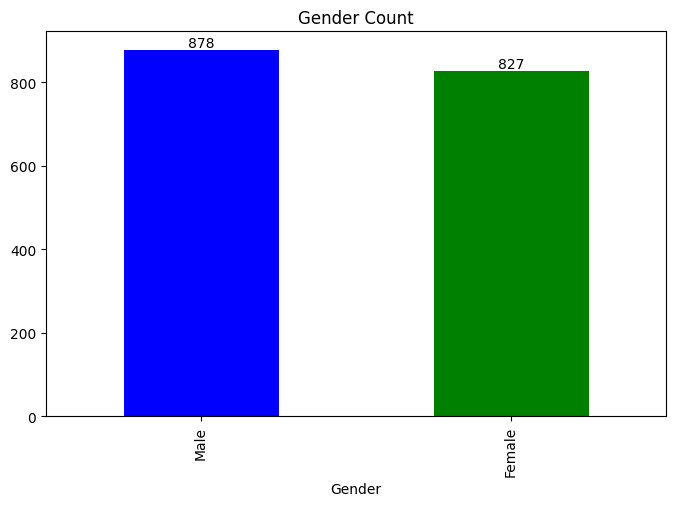

In [14]:
plt.figure(figsize=(8,5))
counts=data['Gender'].value_counts()

at=counts.plot(kind='bar',color=['blue','green'])

for i,v in enumerate(counts):
    at.text(i, v, str(v), ha='center', va='bottom')


plt.title('Gender Count')
plt.show()

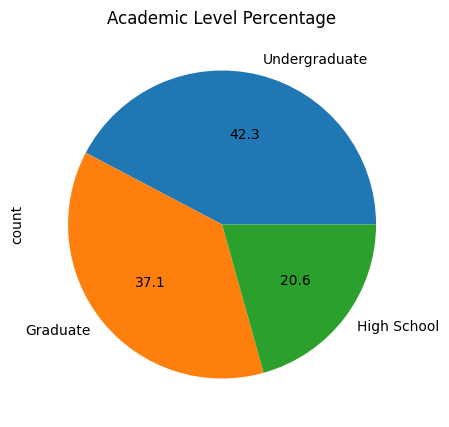

In [15]:
plt.figure(figsize=(8,5))
plt.title('Academic Level Percentage')
data['Academic_Level'].value_counts().plot(kind='pie',normalize=True,autopct='%1.1f')
plt.show()

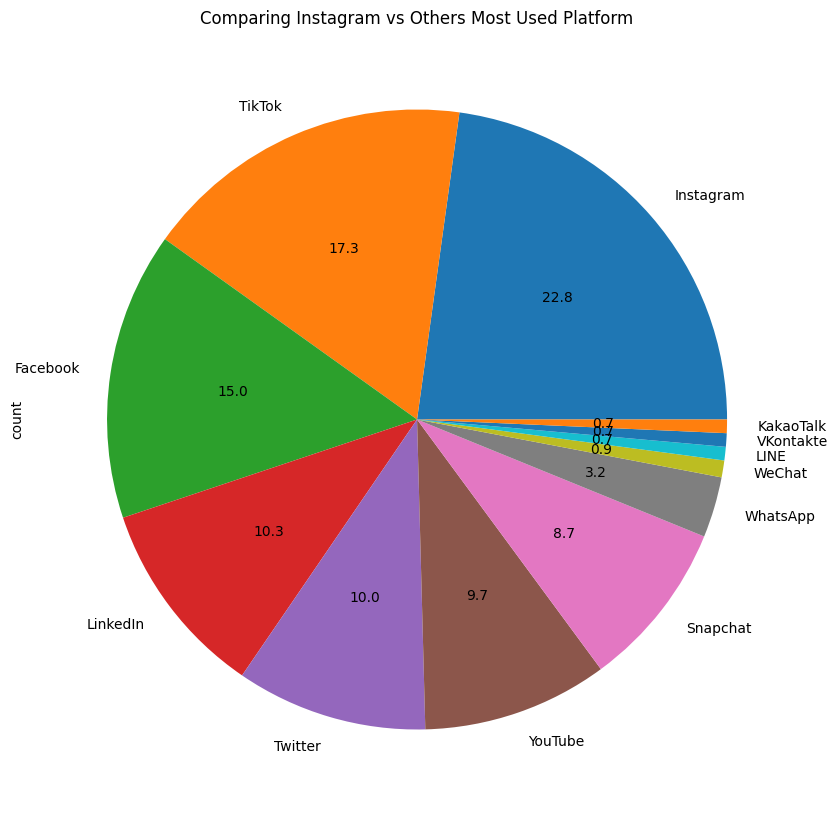

In [16]:
plt.figure(figsize=(10,12))
plt.title('Comparing Instagram vs Others Most Used Platform')
data['Most_Used_Platform'].value_counts().plot(kind='pie',autopct='%1.1f',normalize=True)
plt.show()

We can Clearly observe that Negative has an greater Impact in respect to Positive and Neutral


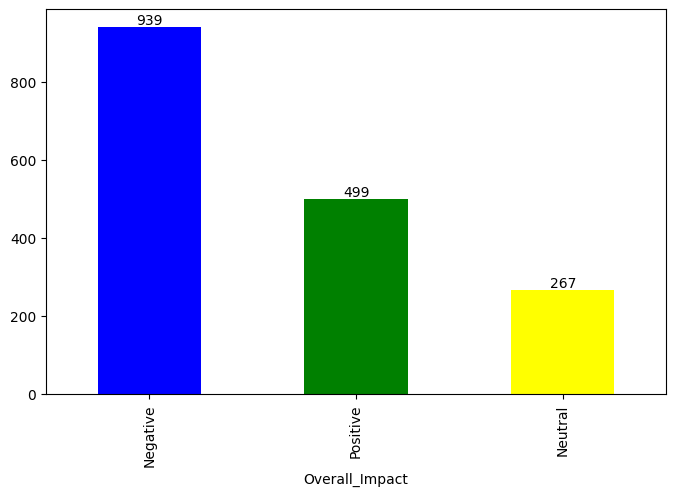

In [17]:
plt.figure(figsize=(8,5))
counts=data['Overall_Impact'].value_counts()
at=counts.plot(kind='bar',color=['blue','green','yellow'])

for i,v in enumerate(counts):
    at.text(i, v, str(v), ha='center', va='bottom')

print('We can Clearly observe that Negative has an greater Impact in respect to Positive and Neutral')
plt.show()

# Bivariate Analysi

In [18]:
pd.crosstab(data['Gender'],data['Most_Used_Platform'],normalize=True)*100

Most_Used_Platform,Facebook,Instagram,KakaoTalk,LINE,LinkedIn,Snapchat,TikTok,Twitter,VKontakte,WeChat,WhatsApp,YouTube
Gender,,,,,,,,,,,,
Female,5.395894,13.841642,0.703812,0.703812,4.633431,3.870968,9.032258,4.809384,0.000000,0.234604,0.645161,4.633431
Male,9.618768,8.973607,0.000000,0.000000,5.689150,4.868035,8.269795,5.161290,0.703812,0.645161,2.521994,5.043988


In [19]:
print('From the above data we can clearly observe that Female tend to have major impact on Instragram over Males')

From the above data we can clearly observe that Female tend to have major impact on Instragram over Males


In [20]:
pd.crosstab(data['Academic_Level'],data['Most_Used_Platform'],normalize=True)*100

Most_Used_Platform,Facebook,Instagram,KakaoTalk,LINE,LinkedIn,Snapchat,TikTok,Twitter,VKontakte,WeChat,WhatsApp,YouTube
Academic_Level,,,,,,,,,,,,
Graduate,7.624633,7.390029,0.000000,0.000000,3.870968,2.228739,5.571848,3.519062,0.703812,0.703812,2.521994,2.932551
High School,2.697947,3.460411,0.000000,0.000000,3.108504,2.991202,3.049853,1.935484,0.000000,0.000000,0.000000,3.401760
Undergraduate,4.692082,11.964809,0.703812,0.703812,3.343109,3.519062,8.680352,4.516129,0.000000,0.175953,0.645161,3.343109


In [21]:
print('We can clearly oberserve that Instagram and Tik Rok have major impact on Undergraduates student as compare to Graduate and High schoolers ')

We can clearly oberserve that Instagram and Tik Rok have major impact on Undergraduates student as compare to Graduate and High schoolers 


In [22]:
print('We can clearly observe that as we move up in  Education ladder LinkedIn have proportional increase from High School > Undergrad > Graduate')

We can clearly observe that as we move up in  Education ladder LinkedIn have proportional increase from High School > Undergrad > Graduate


In [23]:
pd.crosstab(data['Gender'],data['Academic_Level'],normalize=True).mul(100)

Academic_Level,Graduate,High School,Undergraduate
Gender,,,
Female,11.085044,10.087977,27.331378
Male,25.982405,10.557185,14.956012


In [24]:
print('We can clearly observe that Male have higher tendency over Female at Graduation Level while At Undergraduate Female tend to have \n higher portion as compared to Men')

We can clearly observe that Male have higher tendency over Female at Graduation Level while At Undergraduate Female tend to have 
 higher portion as compared to Men


In [25]:
data['Country'].value_counts()

Country
Other          667
India          139
USA            115
Canada          78
Australia       66
              ... 
Oman             1
Afghanistan      1
Syria            1
Yemen            1
Bhutan           1
Name: count, Length: 111, dtype: int64

In [26]:
counts = data['Country'].value_counts()

for i in counts.items():
    print(i)

('Other', 667)
('India', 139)
('USA', 115)
('Canada', 78)
('Australia', 66)
('UK', 66)
('Germany', 46)
('Spain', 27)
('Mexico', 27)
('France', 27)
('Switzerland', 27)
('Turkey', 27)
('Ireland', 27)
('Denmark', 27)
('Japan', 21)
('Russia', 21)
('Italy', 21)
('Bangladesh', 20)
('Nepal', 19)
('Pakistan', 19)
('Maldives', 19)
('Sri Lanka', 19)
('China', 16)
('Poland', 16)
('South Korea', 13)
('UAE', 8)
('Singapore', 8)
('New Zealand', 8)
('Brazil', 8)
('Malaysia', 8)
('Netherlands', 8)
('Finland', 8)
('Austria', 1)
('Thailand', 1)
('Philippines', 1)
('Taiwan', 1)
('Indonesia', 1)
('Hong Kong', 1)
('Israel', 1)
('Egypt', 1)
('Morocco', 1)
('Vietnam', 1)
('Belgium', 1)
('Greece', 1)
('Portugal', 1)
('Sweden', 1)
('Norway', 1)
('Chile', 1)
('Argentina', 1)
('Ghana', 1)
('Kenya', 1)
('Nigeria', 1)
('South Africa', 1)
('Colombia', 1)
('Peru', 1)
('Costa Rica', 1)
('Bolivia', 1)
('Panama', 1)
('Jamaica', 1)
('Uruguay', 1)
('Paraguay', 1)
('Venezuela', 1)
('Ecuador', 1)
('Hungary', 1)
('Czech Rep

# Feature Engineering

In [30]:
def group_country(x):
    if x in ['India','USA','Canada','Australia']:
        return 1
    else:
        return 0
    

data['group_country']=data['Country'].apply(group_country)

group_country_mapping={
    1: 'Powerful Economy Country',
    0 :'Non Powerful Country'
}

data['group_country_mapping']=data['group_country'].map(group_country_mapping)

In [31]:
print('We have taken Powerful Country includes India, USA , Canada and Australia')
data['group_country_mapping'].value_counts()

We have taken Powerful Country includes India, USA , Canada and Australia


group_country_mapping
Non Powerful Country        1307
Powerful Economy Country     398
Name: count, dtype: int64

In [32]:
pd.crosstab(data['Academic_Level'],data['group_country_mapping'],normalize=True).mul(100)

group_country_mapping,Non Powerful Country,Powerful Economy Country
Academic_Level,,
Graduate,28.269795,8.797654
High School,15.483871,5.161290
Undergraduate,32.903226,9.384164


In [33]:
continent_map = {
    # Asia
    'India':'Asia','Pakistan':'Asia','Bangladesh':'Asia','Sri Lanka':'Asia','Nepal':'Asia','Maldives':'Asia',
    'China':'Asia','Japan':'Asia','South Korea':'Asia','Singapore':'Asia','UAE':'Asia','Malaysia':'Asia',
    'Tajikistan':'Asia','Uzbekistan':'Asia','Kyrgyzstan':'Asia','Kazakhstan':'Asia','Afghanistan':'Asia',
    'Syria':'Asia','Yemen':'Asia','Iraq':'Asia','Lebanon':'Asia','Jordan':'Asia','Bahrain':'Asia',
    'Kuwait':'Asia','Qatar':'Asia','Oman':'Asia','Bhutan':'Asia','Israel':'Asia','Hong Kong':'Asia',
    'Taiwan':'Asia','Indonesia':'Asia','Philippines':'Asia','Vietnam':'Asia','Thailand':'Asia',
    'Azerbaijan':'Asia','Armenia':'Asia','Georgia':'Asia','Turkey':'Asia',

    # Europe
    'UK':'Europe','Germany':'Europe','Spain':'Europe','Denmark':'Europe','Ireland':'Europe','France':'Europe',
    'Switzerland':'Europe','Italy':'Europe','Russia':'Europe','Poland':'Europe','Finland':'Europe',
    'Netherlands':'Europe','Luxembourg':'Europe','Malta':'Europe','Cyprus':'Europe','Monaco':'Europe',
    'Belgium':'Europe','San Marino':'Europe','Belarus':'Europe','Moldova':'Europe','Ukraine':'Europe',
    'Lithuania':'Europe','Andorra':'Europe','Albania':'Europe','Vatican City':'Europe','Liechtenstein':'Europe',
    'Bosnia':'Europe','Kosovo':'Europe','North Macedonia':'Europe','Estonia':'Europe','Montenegro':'Europe',
    'Latvia':'Europe','Croatia':'Europe','Bulgaria':'Europe','Slovenia':'Europe','Serbia':'Europe',
    'Norway':'Europe','Greece':'Europe','Portugal':'Europe','Austria':'Europe','Slovakia':'Europe',
    'Czech Republic':'Europe','Hungary':'Europe','Romania':'Europe','Iceland':'Europe','Sweden':'Europe',

    # North America
    'USA':'North America','Canada':'North America','Mexico':'North America',
    'Bahamas':'North America','Jamaica':'North America','Trinidad':'North America','Costa Rica':'North America',
    'Panama':'North America',

    # South America
    'Brazil':'South America','Argentina':'South America','Chile':'South America','Colombia':'South America',
    'Peru':'South America','Bolivia':'South America','Paraguay':'South America','Uruguay':'South America',
    'Ecuador':'South America','Venezuela':'South America',

    # Africa
    'Ghana':'Africa','Kenya':'Africa','Nigeria':'Africa','South Africa':'Africa','Morocco':'Africa','Egypt':'Africa',

    # Oceania / Australia
    'Australia':'Oceania','New Zealand':'Oceania',

    # Others as defined as Others
    'Others':'Others'
}

data['Continental_Country_mapping']=data['Country'].map(continent_map)
print('Note: We have mapped the country which are avaible in the data file respective to the Continennts')


Note: We have mapped the country which are avaible in the data file respective to the Continennts


In [34]:
data['Continental_Country_mapping'].value_counts()

Continental_Country_mapping
Asia             361
Europe           355
North America    225
Oceania           74
South America     17
Africa             6
Name: count, dtype: int64

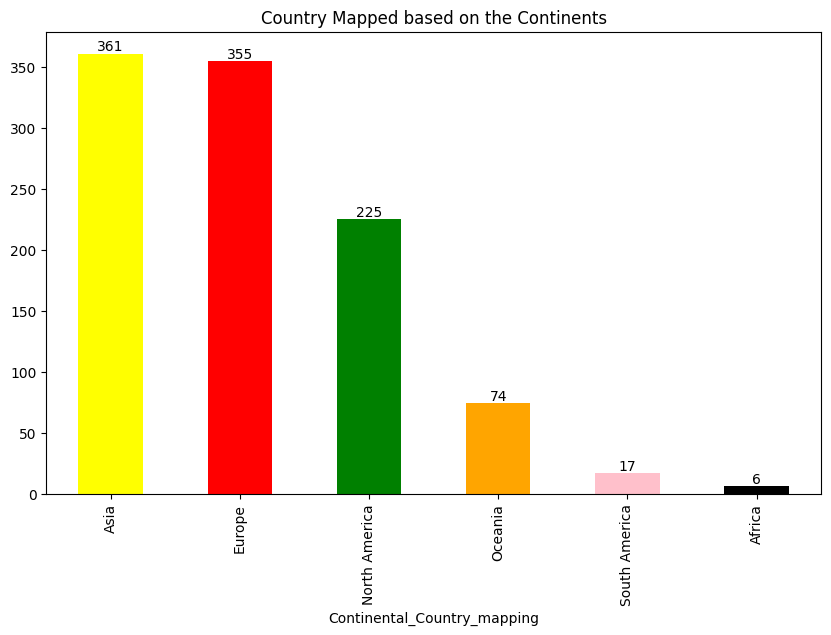

In [35]:
plt.figure(figsize=(10,6))
plt.title('Country Mapped based on the Continents')
counts=data['Continental_Country_mapping'].value_counts()
at=counts.plot(kind='bar', color=['Yellow','Red','Green','Orange','Pink','Black'])

for i,v in enumerate(counts):
    at.text(i, v, str(v), ha='center', va='bottom')

plt.show()

In [36]:
pd.crosstab(data['Academic_Level'],data['Continental_Country_mapping'],normalize=True).mul(100)

Continental_Country_mapping,Africa,Asia,Europe,North America,Oceania,South America
Academic_Level,,,,,,
Graduate,0.096339,15.028902,15.125241,8.863198,2.215800,0.289017
High School,0.096339,4.046243,3.082852,4.046243,1.637765,0.192678
Undergraduate,0.385356,15.703276,15.992293,8.766859,3.275530,1.156069


In [37]:
print("It is evident that Europe is the most preferred destination for pursuing undergraduate and graduate studies compared to other continents.")

It is evident that Europe is the most preferred destination for pursuing undergraduate and graduate studies compared to other continents.


In [38]:
pd.crosstab(data['Gender'],data['Continental_Country_mapping'],normalize=True).mul(100)


Continental_Country_mapping,Africa,Asia,Europe,North America,Oceania,South America
Gender,,,,,,
Female,0.289017,16.473988,17.341040,10.115607,3.468208,1.156069
Male,0.289017,18.304432,16.859345,11.560694,3.660886,0.481696


In [39]:
print("We can clearly observe that a higher percentage of males (18.30%) are in Asia, whereas females show a slightly higher preference for Europe (17.34%).")

We can clearly observe that a higher percentage of males (18.30%) are in Asia, whereas females show a slightly higher preference for Europe (17.34%).


In [40]:
print('Country where data not mapped are:-',data['Continental_Country_mapping'].isnull().sum())
print('While mapping we found that 667 records are not mapped because they were marked as Others in "Country" column in actual data')

Country where data not mapped are:- 667
While mapping we found that 667 records are not mapped because they were marked as Others in "Country" column in actual data


In [41]:
counts = data['Most_Used_Platform'].value_counts()

for i in counts.items():
    print(i)

('Instagram', 389)
('TikTok', 295)
('Facebook', 256)
('LinkedIn', 176)
('Twitter', 170)
('YouTube', 165)
('Snapchat', 149)
('WhatsApp', 54)
('WeChat', 15)
('LINE', 12)
('VKontakte', 12)
('KakaoTalk', 12)


In [42]:
pd.crosstab(data['Affects_Academic_Performance'],data['Most_Used_Platform'],normalize=True).mul(100).round(2)

Most_Used_Platform,Facebook,Instagram,KakaoTalk,LINE,LinkedIn,Snapchat,TikTok,Twitter,VKontakte,WeChat,WhatsApp,YouTube
Affects_Academic_Performance,,,,,,,,,,,,
No,8.33,8.50,0.0,0.7,5.87,3.23,4.05,4.52,0.7,0.41,0.00,4.40
Yes,6.69,14.31,0.7,0.0,4.46,5.51,13.26,5.45,0.0,0.47,3.17,5.28


In [43]:
print('By  Looking at the data we clearly found that Instagram (14%), TikTok (13%) has affecting the students Academic Performance.')

By  Looking at the data we clearly found that Instagram (14%), TikTok (13%) has affecting the students Academic Performance.


In [44]:
print("We can clearly conclude that on Average resposners spent ",data['Avg_Daily_Usage_Hours'].describe().round(2)[1],"hours  per day on social media")


We can clearly conclude that on Average resposners spent  5.1 hours  per day on social media


In [45]:
data['Avg_Daily_Usage_Hours'].describe()

count    1705.000000
mean        5.103636
std         1.677341
min         1.500000
25%         3.800000
50%         5.100000
75%         6.300000
max         8.500000
Name: Avg_Daily_Usage_Hours, dtype: float64

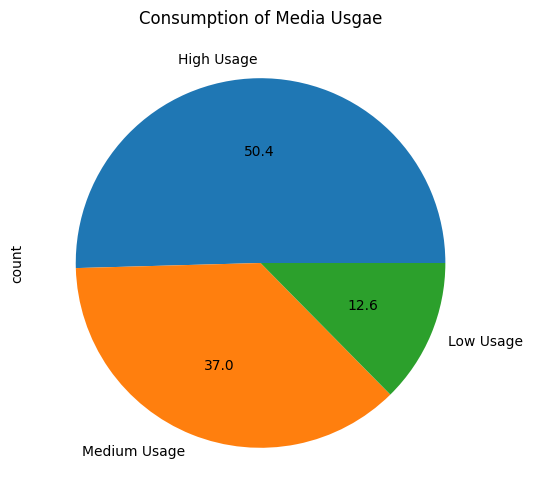

In [48]:
plt.figure(figsize=(8,6))
data['Avg_Daily_Usage_Hours_Values'].value_counts().plot(kind='pie',autopct='%1.1f')
plt.title('Consumption of Media Usgae')
plt.show()

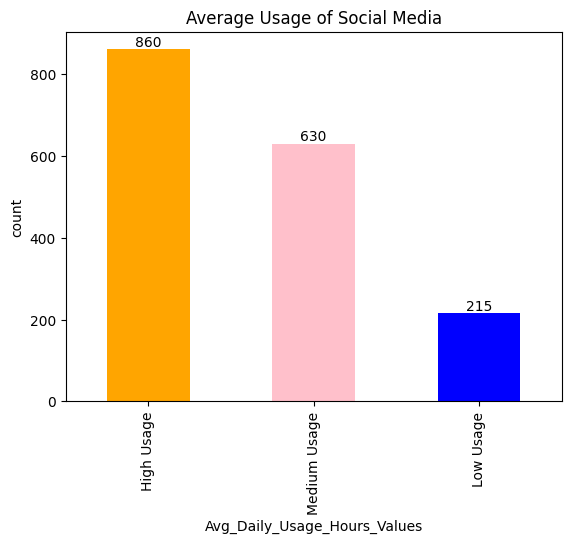

In [47]:
data['Avg_Daily_Usage_Hours_Values']=pd.cut(data['Avg_Daily_Usage_Hours'],
                                           bins=[0,3,5,10],
                                           labels=['Low Usage','Medium Usage','High Usage'])

counts=data['Avg_Daily_Usage_Hours_Values'].value_counts()
ax=counts.plot(kind='bar',color=['orange','pink','blue'])
plt.title('Average Usage of Social Media')
plt.ylabel('count')

for i,v in enumerate(counts):
    ax.text(i, v, str(v), ha='center', va='bottom')

plt.show()

In [49]:
pd.crosstab(data['Gender'],data['Avg_Daily_Usage_Hours_Values'], normalize=True).mul(100).round(2)


Avg_Daily_Usage_Hours_Values,Low Usage,Medium Usage,High Usage
Gender,,,
Female,5.98,17.71,24.81
Male,6.63,19.24,25.63


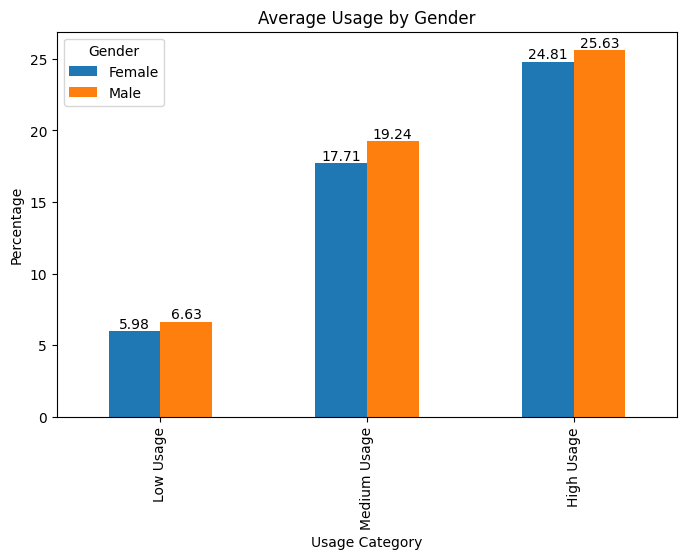

In [50]:
sp=pd.DataFrame({
    'Low Usage':[5.98,6.63],
    'Medium Usage':[17.71,19.24],
    'High Usage':[24.81,25.63]
}, index=['Female','Male'])

ax = sp.T.plot(kind='bar', figsize=(8,5))

plt.title('Average Usage by Gender')
plt.xlabel('Usage Category')
plt.ylabel('Percentage')

for container in ax.containers:
    ax.bar_label(container, fmt='%.2f')

plt.legend(title='Gender')
plt.show()

In [51]:
pd.crosstab(data['Age'],data['Avg_Daily_Usage_Hours_Values'], normalize=True).mul(100).round(2)

Avg_Daily_Usage_Hours_Values,Low Usage,Medium Usage,High Usage
Age,,,
18,1.41,2.05,5.69
19,1.70,6.63,9.38
20,1.94,7.74,7.92
21,1.58,7.62,9.56
22,2.11,7.16,8.15
23,2.35,2.82,5.04
24,1.52,2.93,4.69


In [52]:
print(" Observation 1: Across all age groups, high usage dominates, indicating a strong tendency toward heavy social media use among respondents.")

 Observation 1: Across all age groups, high usage dominates, indicating a strong tendency toward heavy social media use among respondents.


In [53]:
print("Trend Analysis: Social media usage increases from age 18 and peaks around 20–21, after which it gradually declines.")

Trend Analysis: Social media usage increases from age 18 and peaks around 20–21, after which it gradually declines.


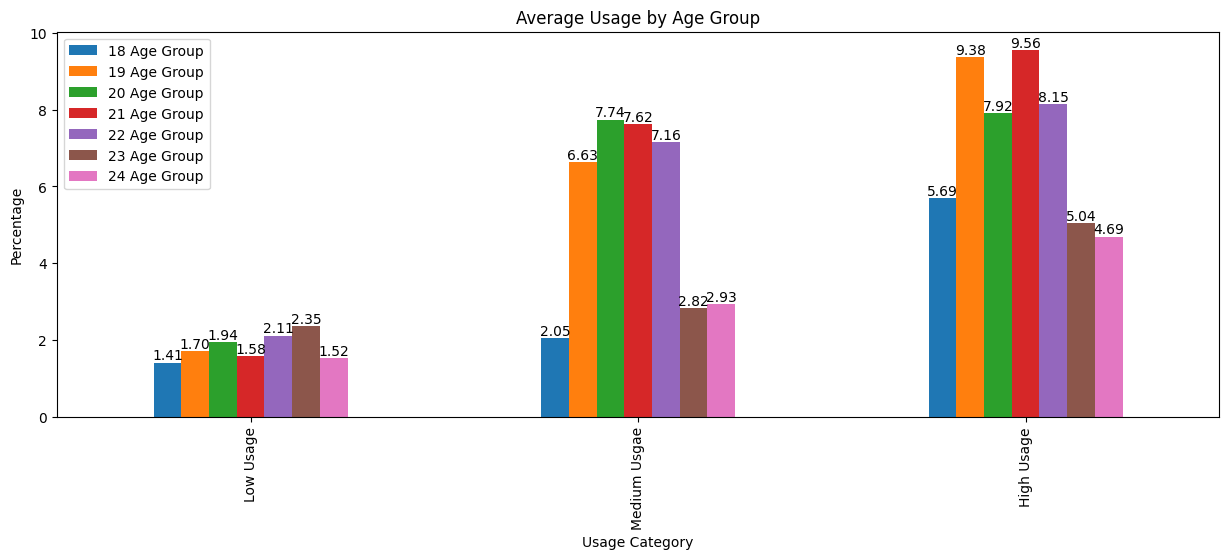

In [54]:
age=pd.DataFrame({
    'Low Usage':[1.41,1.70,1.94,1.58,2.11,2.35,1.52],
    'Medium Usgae':[2.05,6.63,7.74,7.62,7.16,2.82,2.93],
    'High Usage':[5.69,9.38,7.92,9.56,8.15,5.04,4.69]},
index=['18 Age Group','19 Age Group','20 Age Group','21 Age Group','22 Age Group','23 Age Group','24 Age Group'])


axt = age.T.plot(kind='bar', figsize=(15,5))

plt.title('Average Usage by Age Group')
plt.xlabel('Usage Category')
plt.ylabel('Percentage')

for container in axt.containers:
    axt.bar_label(container, fmt='%.2f')

plt.show()

In [55]:
data['Age_Category']=pd.cut(data['Age'], bins=[18,19,22,24], labels=["Early-stage students (18–19)", "Mid-stage students (20–22)", "Senior/Mature students (23–24)"])
data['Age_Category'].value_counts()

Age_Category
Mid-stage students (20–22)        917
Senior/Mature students (23–24)    330
Early-stage students (18–19)      302
Name: count, dtype: int64

In [56]:
pd.crosstab(data['Age_Category'],data['Avg_Daily_Usage_Hours_Values'], normalize=True).mul(100).round(2)

Avg_Daily_Usage_Hours_Values,Low Usage,Medium Usage,High Usage
Age_Category,,,
Early-stage students (18–19),1.87,7.30,10.33
Mid-stage students (20–22),6.20,24.79,28.21
Senior/Mature students (23–24),4.26,6.33,10.72


In [57]:
pd.crosstab(data['Age_Category'],data['Most_Used_Platform'], normalize=True).mul(100).round(2)

Most_Used_Platform,Facebook,Instagram,KakaoTalk,LINE,LinkedIn,Snapchat,TikTok,Twitter,VKontakte,WeChat,WhatsApp,YouTube
Age_Category,,,,,,,,,,,,
Early-stage students (18–19),1.61,6.58,0.00,0.77,1.61,0.97,3.94,1.68,0.00,0.13,0.52,1.68
Mid-stage students (20–22),11.04,13.62,0.77,0.00,4.84,3.81,10.78,4.52,0.77,0.71,2.97,5.36
Senior/Mature students (23–24),2.71,3.62,0.00,0.00,3.29,2.91,3.03,3.16,0.00,0.13,0.00,2.45


In [58]:
print(' As we group the category we clearly observe that, Mid-stage students have high usage dominates towards social media usage.')

 As we group the category we clearly observe that, Mid-stage students have high usage dominates towards social media usage.


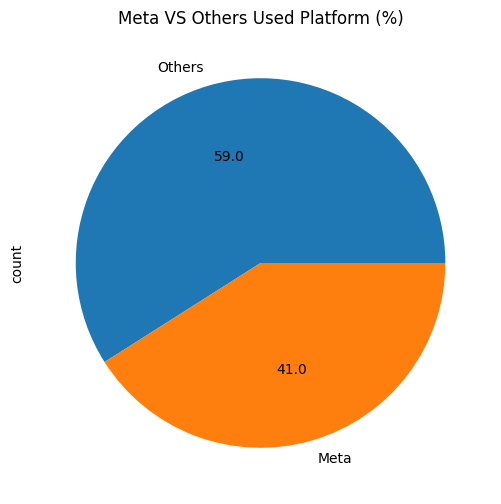

Meta-owned platforms constitute 41% of the total platforms considered, while the remaining are owned by other companies.


In [59]:
platform={
   'Facebook' :'Meta',
'Instagram' :'Meta',
'KakaoTalk' :'Others',
'LINE' :'Others',
'LinkedIn' :'Others',
'Snapchat' :'Others',
'TikTok' :'Others',
'Twitter' :'Others',
'VKontakte' :'Others',
'WeChat' :'Others',
'WhatsApp' :'Meta',
'YouTube' :'Others',
}

data['Meta_vs_others']=data['Most_Used_Platform'].map(platform)

plt.figure(figsize=(8,6))
data['Meta_vs_others'].value_counts().plot(kind='pie',autopct='%1.1f')
plt.title('Meta VS Others Used Platform (%)')
plt.show()

print("Meta-owned platforms constitute 41% of the total platforms considered, while the remaining are owned by other companies.")


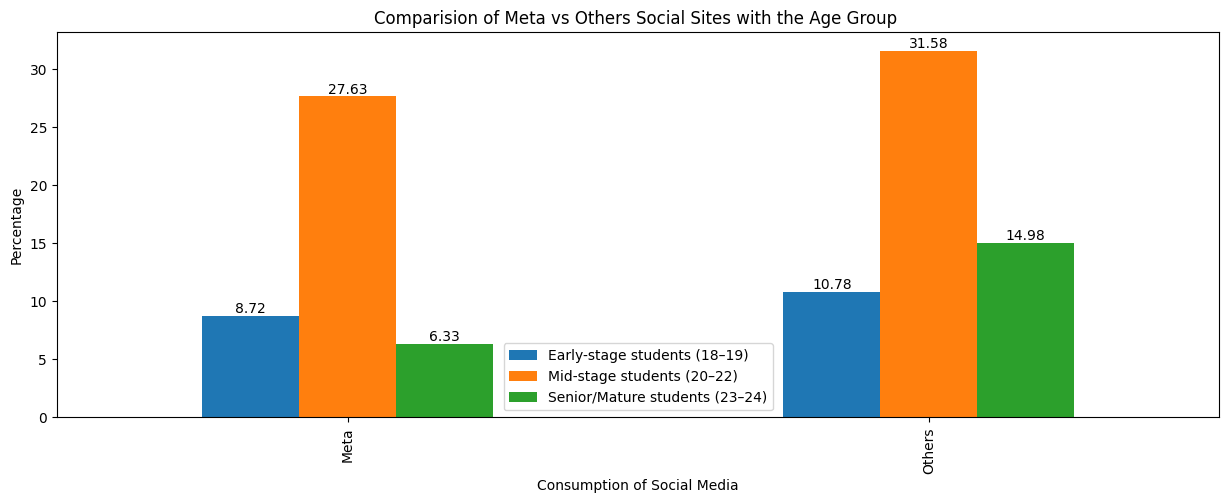

In [60]:
pd.crosstab(data['Age_Category'], data['Meta_vs_others'],normalize=True).mul(100).round(2)



meta_others=pd.DataFrame({
    'Meta':[8.72,27.63,6.33],
    'Others':[10.78,31.58,14.98]
},index=['Early-stage students (18–19)','Mid-stage students (20–22)','Senior/Mature students (23–24)'])

axtt = meta_others.T.plot(kind='bar', figsize=(15,5))

plt.title('Comparision of Meta vs Others Social Sites with the Age Group ')
plt.xlabel('Consumption of Social Media')
plt.ylabel('Percentage')

for container in axtt.containers:
    axtt.bar_label(container, fmt='%.2f')



In [61]:
print(pd.crosstab(data['Avg_Daily_Usage_Hours_Values'], data['Meta_vs_others'],normalize=True).mul(100).round(2))
print("\n")
print("Observation: A clear upward trend is observed across usage categories, with higher values in the high-usage group for both Meta and other platforms. However, non-Meta platforms exhibit a steeper increase, suggesting that heavy users are more inclined toward a diverse set of platforms \nbeyond Meta.")

Meta_vs_others                 Meta  Others
Avg_Daily_Usage_Hours_Values               
Low Usage                      3.81    8.80
Medium Usage                  17.89   19.06
High Usage                    19.30   31.14


Observation: A clear upward trend is observed across usage categories, with higher values in the high-usage group for both Meta and other platforms. However, non-Meta platforms exhibit a steeper increase, suggesting that heavy users are more inclined toward a diverse set of platforms 
beyond Meta.


# Multivariate analysis

In [62]:
print(pd.crosstab([data['Gender'], data['Meta_vs_others']],data['Overall_Impact'],normalize=True).mul(100).round(2))
print('Observation: We can clearly found out that Female has more negative impact on Social Platform as compared with Mens')

Overall_Impact         Negative  Neutral  Positive
Gender Meta_vs_others                             
Female Meta               11.14     1.52      7.21
       Others             15.84     6.04      6.74
Male   Meta               12.61     2.23      6.28
       Others             15.48     5.87      9.03
Observation: We can clearly found out that Female has more negative impact on Social Platform as compared with Mens


In [63]:
print(pd.crosstab([data['Age_Category'], data['Meta_vs_others']],data['Overall_Impact'],normalize=True).mul(100).round(2))
print('Observation: The findings indicate that students in the 20–22 age group report the highest levels of negative impact from social media across both Meta and other platforms, compared to other age groups.')

Overall_Impact                                 Negative  Neutral  Positive
Age_Category                   Meta_vs_others                             
Early-stage students (18–19)   Meta                5.42     0.71      2.58
                               Others              5.68     3.36      1.74
Mid-stage students (20–22)     Meta               16.46     1.87      9.30
                               Others             17.95     4.97      8.65
Senior/Mature students (23–24) Meta                2.78     1.23      2.32
                               Others              6.65     3.16      5.16
Observation: The findings indicate that students in the 20–22 age group report the highest levels of negative impact from social media across both Meta and other platforms, compared to other age groups.


In [64]:
print(pd.crosstab([data['Academic_Level'], data['Meta_vs_others']],data['Overall_Impact'],normalize=True).mul(100).round(2))

print('Observation: We can clearly observe that as we move across academic levels, the negative impact varies across platform types. At the High School level, Meta shows a lower negative impact (3.40%) as compared to Others (6.74%). This gap widens further at the Undergraduate level, where Others (14.90%) significantly exceed Meta (9.27%), indicating a stronger negative influence of non-Meta platforms in this group. However, at the Graduate level, the pattern slightly reverses, with Meta (11.09%) showing a higher negative impact than Others (9.68%), suggesting a shift in platform effect at higher academic levels.')

Overall_Impact                 Negative  Neutral  Positive
Academic_Level Meta_vs_others                             
Graduate       Meta               11.09     1.23      5.22
               Others              9.68     3.64      6.22
High School    Meta                3.40     1.29      1.47
               Others              6.74     3.81      3.93
Undergraduate  Meta                9.27     1.23      6.80
               Others             14.90     4.46      5.63
Observation: We can clearly observe that as we move across academic levels, the negative impact varies across platform types. At the High School level, Meta shows a lower negative impact (3.40%) as compared to Others (6.74%). This gap widens further at the Undergraduate level, where Others (14.90%) significantly exceed Meta (9.27%), indicating a stronger negative influence of non-Meta platforms in this group. However, at the Graduate level, the pattern slightly reverses, with Meta (11.09%) showing a higher negative impact 

# Hypothesis Testing

In [ ]:
H₀: Social media usage has no association with overall impact on students  
H₁: Social media usage has an association with overall impact on students  

In [65]:
from scipy.stats import chi2_contingency

table = pd.crosstab(
    data['Avg_Daily_Usage_Hours_Values'],
    data['Overall_Impact']
)

chi2, p, dof, expected = chi2_contingency(table)

print("p-value:", p)

if p < 0.05:
    print('We reject the Null Hypothesis. Therefore, Social media usage has an association with overall impact on students.')
else:
    print('We fail to reject the Null Hypothesis. Therefore, there is no significant association between social media usage and overall impact.')

p-value: 6.73817251922788e-233
We reject the Null Hypothesis. Therefore, Social media usage has an association with overall impact on students.


# Machine Learning

# Serparte numerical and categorical Columns for running ML algorithms

In [67]:
num_cols=data.select_dtypes(include=['int64'])
cat_cols=data.select_dtypes(include=['object','category'])

In [68]:
num_cols=num_cols.drop(columns=['Student_ID'])

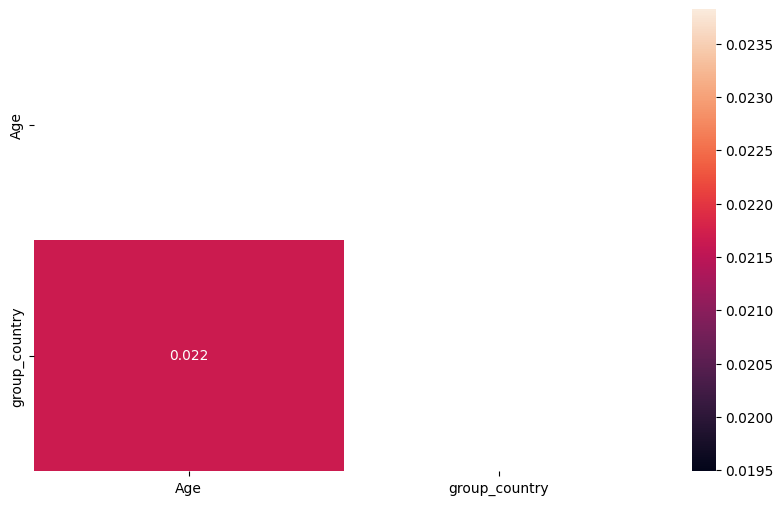

In [69]:
plt.figure(figsize=(10,6))
mask=np.triu(np.ones_like(num_cols.corr(), dtype=bool))
sns.heatmap(num_cols.corr(), annot=True,mask=mask)
plt.show()


In [70]:
Overall_Impact_Num={
    "Neutral":0,
    "Negative":-1,
    "Positive":1
}

data['Overall_Impact_Num']=data['Overall_Impact'].map(Overall_Impact_Num)

In [71]:
num_cols.info()

<class 'pandas.core.frame.DataFrame'>
RangeIndex: 1705 entries, 0 to 1704
Data columns (total 2 columns):
 #   Column         Non-Null Count  Dtype
---  ------         --------------  -----
 0   Age            1705 non-null   int64
 1   group_country  1705 non-null   int64
dtypes: int64(2)
memory usage: 26.8 KB


In [72]:
cat_cols.info()

<class 'pandas.core.frame.DataFrame'>
RangeIndex: 1705 entries, 0 to 1704
Data columns (total 11 columns):
 #   Column                        Non-Null Count  Dtype   
---  ------                        --------------  -----   
 0   Gender                        1705 non-null   object  
 1   Academic_Level                1705 non-null   object  
 2   Country                       1705 non-null   object  
 3   Most_Used_Platform            1705 non-null   object  
 4   Affects_Academic_Performance  1705 non-null   object  
 5   Overall_Impact                1705 non-null   object  
 6   group_country_mapping         1705 non-null   object  
 7   Continental_Country_mapping   1038 non-null   object  
 8   Avg_Daily_Usage_Hours_Values  1705 non-null   category
 9   Age_Category                  1549 non-null   category
 10  Meta_vs_others                1705 non-null   object  
dtypes: category(2), object(9)
memory usage: 123.6+ KB


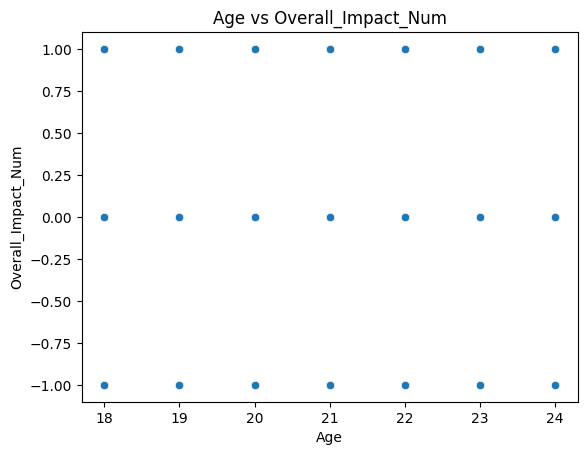

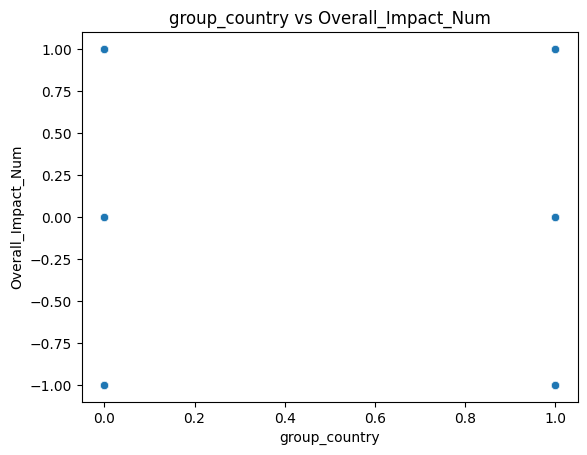

In [73]:
import seaborn as sns
import matplotlib.pyplot as plt

for col in num_cols:
    plt.figure()
    sns.scatterplot(x=data[col], y=data['Overall_Impact_Num'])
    plt.title(f'{col} vs Overall_Impact_Num')
    plt.show()

In [74]:
data=data.drop(columns=['Overall_Impact_Num'])
X=data.drop('Overall_Impact',axis=1)
Y=data['Overall_Impact']

In [75]:
X=pd.get_dummies(X,drop_first=True)

In [76]:
from sklearn.preprocessing import LabelEncoder

le=LabelEncoder()
y=le.fit_transform(Y)

In [77]:
from sklearn.model_selection import train_test_split

X_train,X_test,Y_train,Y_test=train_test_split(X,Y,test_size=0.2,random_state=42)

In [78]:
from sklearn.linear_model import LogisticRegression

model=LogisticRegression()
model.fit(X_train,Y_train)

LogisticRegression()

In [79]:
y_pred=model.predict(X_test)

In [80]:
from sklearn.metrics import accuracy_score, classification_report

print(accuracy_score(Y_test, y_pred))
print(classification_report(Y_test, y_pred)) 


0.9237536656891495
              precision    recall  f1-score   support

    Negative       0.96      0.95      0.96       197
     Neutral       0.86      0.73      0.79        51
    Positive       0.88      0.97      0.92        93

    accuracy                           0.92       341
   macro avg       0.90      0.88      0.89       341
weighted avg       0.92      0.92      0.92       341



In [81]:
class_weight='balanced'

from sklearn.ensemble import RandomForestClassifier

rf=RandomForestClassifier(class_weight='balanced')



In [82]:
rf.fit(X_train,Y_train)
print(classification_report(Y_test, y_pred)) 

              precision    recall  f1-score   support

    Negative       0.96      0.95      0.96       197
     Neutral       0.86      0.73      0.79        51
    Positive       0.88      0.97      0.92        93

    accuracy                           0.92       341
   macro avg       0.90      0.88      0.89       341
weighted avg       0.92      0.92      0.92       341



# Features Importance

In [83]:
importance = pd.Series(rf.feature_importances_, index=X.columns)
importance.sort_values(ascending=False).head(10)

Mental_Health_Score                          0.283131
Sleep_Hours_Per_Night                        0.173474
Avg_Daily_Usage_Hours                        0.124805
Affects_Academic_Performance_Yes             0.062912
Avg_Daily_Usage_Hours_Values_High Usage      0.056874
Student_ID                                   0.038848
Avg_Daily_Usage_Hours_Values_Medium Usage    0.026450
Country_Other                                0.019653
Age                                          0.019639
Continental_Country_mapping_Europe           0.012429
dtype: float64

# Prediction

In [85]:
new_data=pd.DataFrame({
    'Age':45,
    'Gender':['Female'],
    'Country':['India'],
    'Avg_Daily_Usage_Hours': [6],
    'Most_Used_Platform': ['Instagram'],
    'Sleep_Hours_Per_Night': [6],
    'Mental_Health_Score': [10],
    'group_country': [1],
    'group_country_mapping': ['Developing'],
    'Meta_vs_others': ['Meta']
    
})

new_data=pd.get_dummies(new_data)
new_data = new_data.reindex(columns=X_train.columns, fill_value=0)

prediction=rf.predict(new_data)
print(prediction)

['Positive']


By Himanshu Kapoor